In [6]:
import time
import torch
import numpy as np
from pathlib import Path
from math import sqrt
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import pairwise_distances
from torch.nn import Sequential, Linear, ReLU

from lmi import LMI
from utils import get_dataset_shape, sample_train_subset, load_queries


# --- Config ---
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

dataset = Path('../../data2024/laion2B-en-clip768v2-n=300K.h5')
sample_sizes = [200, 1000, 2000, 5000, 10000, 15000, 20000, 25000]
# sample_sizes = [100, 200, 500, 1000, 2000]
chunk_size = 100_000
reduced_dim = 100
niter = 5
k = 30

results = {size: {"rust": [], "sklearn": []} for size in sample_sizes}

for sample_size in sample_sizes:
    print(f"\nRunning benchmark for sample_size = {sample_size}")

    for i in range(niter):
        n_data, data_dim_original = get_dataset_shape(dataset)

        X_train = sample_train_subset(dataset, n_data, data_dim_original, sample_size, chunk_size).to(torch.float32)
        queries = load_queries().to(torch.float32)

        def get_top_k(X, Q, k=30):
            dists = pairwise_distances(Q, X, metric="cosine")
            return np.argsort(dists, axis=1)[:, :k]

        def recall_at_k(true_indices, approx_indices, k=30):
            return np.mean([
                len(set(true[:k]) & set(approx[:k])) / k
                for true, approx in zip(true_indices, approx_indices)
            ])

        true_nn = get_top_k(X_train, queries, k=k)

        model = Sequential(Linear(data_dim_original, 512), ReLU(), Linear(512, int(sqrt(sample_size))))

        start = time.time()
        lmi = LMI(model, int(sqrt(sample_size)), data_dim_original)
        lmi._fit_tsvd(X_train, reduced_dim)
        fit_time = time.time() - start

        start = time.time()
        X_train_reduced = lmi.transform_tsvd(X_train).numpy()
        queries_reduced = lmi.transform_tsvd(queries).numpy()
        transform_time = time.time() - start

        approx_nn = get_top_k(X_train_reduced, queries_reduced, k=k)
        recall = recall_at_k(true_nn, approx_nn, k=k)

        results[sample_size]["rust"].append({
            "fit_time": fit_time,
            "transform_time": transform_time,
            "recall": recall
        })

        print(f"[LMI] Iter {i+1}/{niter} | Fit: {fit_time:.2f}s | Transform: {transform_time:.2f}s | Recall@{k}: {recall:.4f}")

        svd = TruncatedSVD(n_components=reduced_dim)

        start = time.time()
        svd.fit(X_train)
        fit_time = time.time() - start

        start = time.time()
        X_train_reduced = svd.transform(X_train)
        queries_reduced = svd.transform(queries)
        transform_time = time.time() - start

        approx_nn = get_top_k(X_train_reduced, queries_reduced, k=k)
        recall = recall_at_k(true_nn, approx_nn, k=k)

        results[sample_size]["sklearn"].append({
            "fit_time": fit_time,
            "transform_time": transform_time,
            "recall": recall
        })

        print(f"[Sklearn] Fit: {fit_time:.2f}s | Transform: {transform_time:.2f}s | Recall@{k}: {recall:.4f}")


2025-05-21 14:42:33.813 | DEBUG    | utils:wrapper_measure_runtime:30 - Execution of load_chunk took 0.060308s.
2025-05-21 14:42:33.887 | DEBUG    | utils:wrapper_measure_runtime:30 - Execution of load_chunk took 0.072204s.



Running benchmark for sample_size = 200


2025-05-21 14:42:33.960 | DEBUG    | utils:wrapper_measure_runtime:30 - Execution of load_chunk took 0.069434s.
2025-05-21 14:42:34.179 | DEBUG    | utils:wrapper_measure_runtime:30 - Execution of sample_train_subset took 0.42666s.


Setting dimensionality to 100
[LMI] Iter 1/5 | Fit: 0.11s | Transform: 0.09s | Recall@30: 0.8896


2025-05-21 14:42:35.455 | DEBUG    | utils:wrapper_measure_runtime:30 - Execution of load_chunk took 0.085229s.
2025-05-21 14:42:35.528 | DEBUG    | utils:wrapper_measure_runtime:30 - Execution of load_chunk took 0.070594s.


...

Setting dimensionality to 100
[LMI] Iter 4/5 | Fit: 3.26s | Transform: 0.19s | Recall@30: 0.6088


2025-05-21 14:50:01.951 | DEBUG    | utils:wrapper_measure_runtime:30 - Execution of load_chunk took 0.063231s.
2025-05-21 14:50:02.033 | DEBUG    | utils:wrapper_measure_runtime:30 - Execution of load_chunk took 0.075618s.


[Sklearn] Fit: 2.47s | Transform: 0.04s | Recall@30: 0.6111


2025-05-21 14:50:02.106 | DEBUG    | utils:wrapper_measure_runtime:30 - Execution of load_chunk took 0.066024s.
2025-05-21 14:50:02.252 | DEBUG    | utils:wrapper_measure_runtime:30 - Execution of sample_train_subset took 0.36534s.


Setting dimensionality to 100
[LMI] Iter 5/5 | Fit: 2.94s | Transform: 0.24s | Recall@30: 0.6067
[Sklearn] Fit: 2.19s | Transform: 0.04s | Recall@30: 0.6094



--- Aggregated Results ---

Sample Size: 200
  Rust (Petal):
    Avg Fit Time:      0.138s
    Avg Transform Time: 0.090s
    Avg Recall@30:      0.8853
  Sklearn (TruncatedSVD):
    Avg Fit Time:      0.480s
    Avg Transform Time: 0.062s
    Avg Recall@30:      0.8909

Sample Size: 1000
  Rust (Petal):
    Avg Fit Time:      0.165s
    Avg Transform Time: 0.099s
    Avg Recall@30:      0.7489
  Sklearn (TruncatedSVD):
    Avg Fit Time:      0.580s
    Avg Transform Time: 0.034s
    Avg Recall@30:      0.7538

Sample Size: 2000
  Rust (Petal):
    Avg Fit Time:      0.303s
    Avg Transform Time: 0.101s
    Avg Recall@30:      0.7058
  Sklearn (TruncatedSVD):
    Avg Fit Time:      0.750s
    Avg Transform Time: 0.034s
    Avg Recall@30:      0.7094

Sample Size: 5000
  Rust (Petal):
    Avg Fit Time:      0.570s
    Avg Transform Time: 0.129s
    Avg Recall@30:      0.6643
  Sklearn (TruncatedSVD):
    Avg Fit Time:      1.763s
    Avg Transform Time: 0.034s
    Avg Recall@30:      

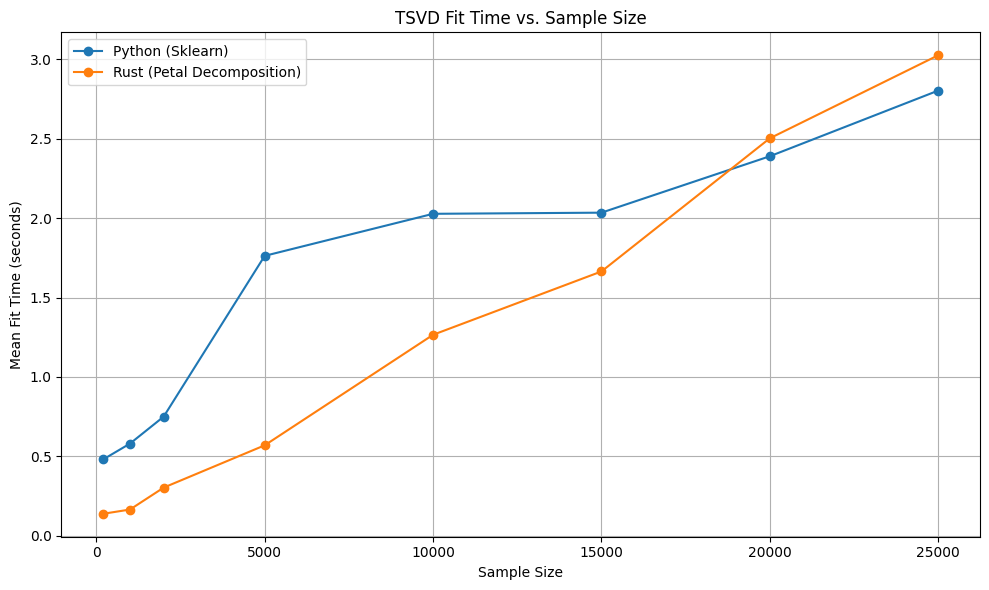

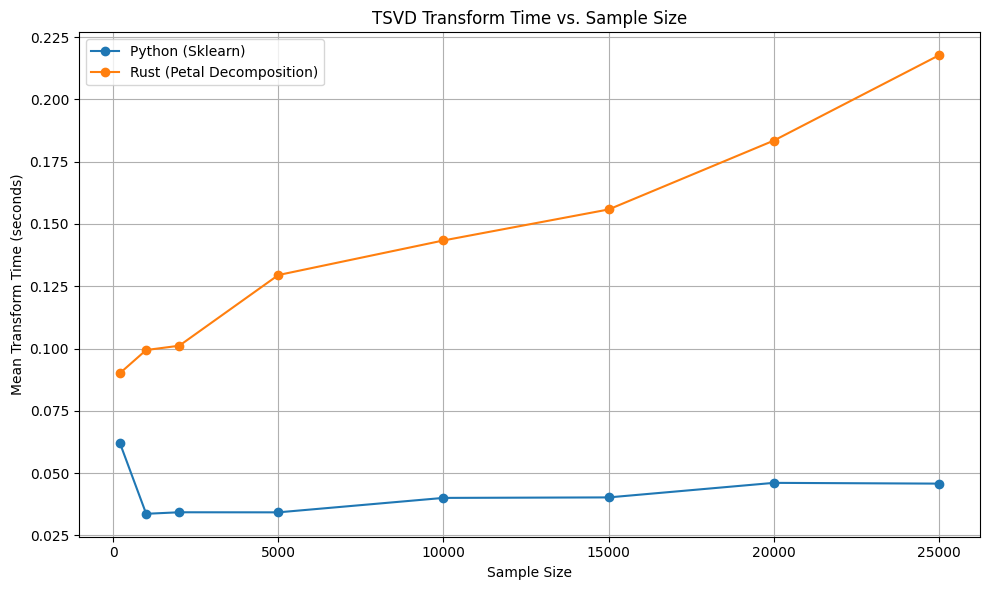

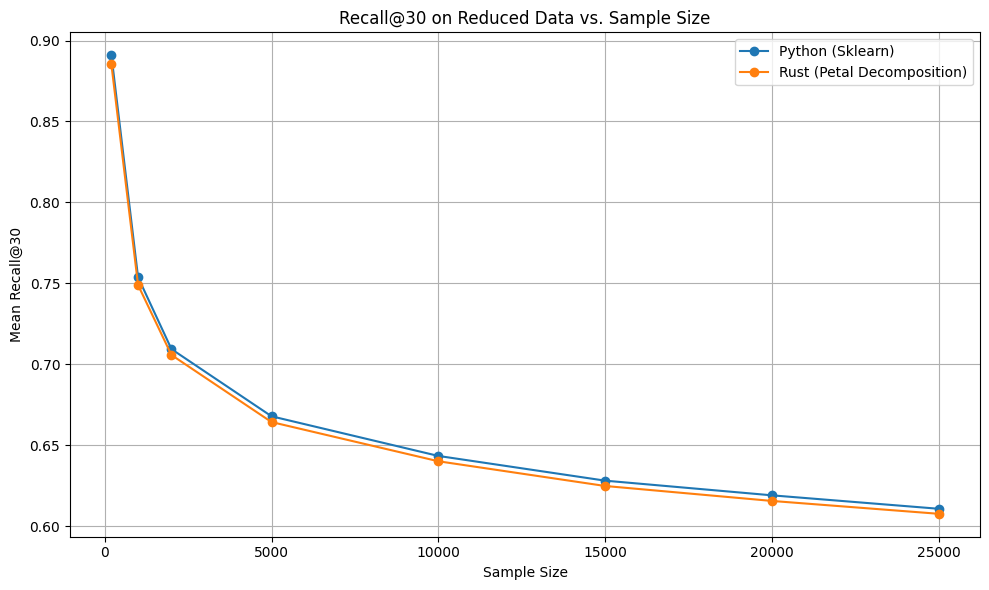


Plots generated and saved to separate files


In [7]:
import matplotlib.pyplot as plt

print("\n--- Aggregated Results ---")

plot_sample_sizes = sorted(results.keys())

mean_fit_times_rust = []
mean_transform_times_rust = []
mean_recalls_rust = []

mean_fit_times_sklearn = []
mean_transform_times_sklearn = []
mean_recalls_sklearn = []

for size in plot_sample_sizes:
    rust_iter_results = results[size]["rust"]
    sklearn_iter_results = results[size]["sklearn"]

    mean_fit_times_rust.append(np.mean([res["fit_time"] for res in rust_iter_results]))
    mean_transform_times_rust.append(np.mean([res["transform_time"] for res in rust_iter_results]))
    mean_recalls_rust.append(np.mean([res["recall"] for res in rust_iter_results]))
    mean_fit_times_sklearn.append(np.mean([res["fit_time"] for res in sklearn_iter_results]))
    mean_transform_times_sklearn.append(np.mean([res["transform_time"] for res in sklearn_iter_results]))
    mean_recalls_sklearn.append(np.mean([res["recall"] for res in sklearn_iter_results]))

    print(f"\nSample Size: {size}")
    if rust_iter_results:
        print(f"  Rust (Petal):")
        print(f"    Avg Fit Time:      {mean_fit_times_rust[-1]:.3f}s")
        print(f"    Avg Transform Time: {mean_transform_times_rust[-1]:.3f}s")
        print(f"    Avg Recall@{k}:      {mean_recalls_rust[-1]:.4f}")
    if sklearn_iter_results:
        print(f"  Sklearn (TruncatedSVD):")
        print(f"    Avg Fit Time:      {mean_fit_times_sklearn[-1]:.3f}s")
        print(f"    Avg Transform Time: {mean_transform_times_sklearn[-1]:.3f}s")
        print(f"    Avg Recall@{k}:      {mean_recalls_sklearn[-1]:.4f}")

# Plot 1: Fit Time
plt.figure(figsize=(10, 6))
plt.plot(plot_sample_sizes, mean_fit_times_sklearn, marker='o', linestyle='-', label='Python (Sklearn)')
plt.plot(plot_sample_sizes, mean_fit_times_rust, marker='o', linestyle='-', label='Rust (Petal Decomposition)')
plt.xlabel('Sample Size')
plt.ylabel('Mean Fit Time (seconds)')
plt.title('TSVD Fit Time vs. Sample Size')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('svd_fit_time_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Transform Time
plt.figure(figsize=(10, 6))
plt.plot(plot_sample_sizes, mean_transform_times_sklearn, marker='o', linestyle='-', label='Python (Sklearn)')
plt.plot(plot_sample_sizes, mean_transform_times_rust, marker='o', linestyle='-', label='Rust (Petal Decomposition)')
plt.xlabel('Sample Size')
plt.ylabel('Mean Transform Time (seconds)')
plt.title('TSVD Transform Time vs. Sample Size')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('svd_transform_time_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 3: Recall
plt.figure(figsize=(10, 6))
plt.plot(plot_sample_sizes, mean_recalls_sklearn, marker='o', linestyle='-', label='Python (Sklearn)')
plt.plot(plot_sample_sizes, mean_recalls_rust, marker='o', linestyle='-', label='Rust (Petal Decomposition)')
plt.xlabel('Sample Size')
plt.ylabel(f'Mean Recall@{k}')
plt.title(f'Recall@{k} on Reduced Data vs. Sample Size')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('svd_recall_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPlots generated and saved to separate files")